# Bagging — Playground Series S6E4: Predicting Irrigation Need

Random Forest with Optuna tuning. Compares class-weighted vs unweighted models. Reports both macro F1 and accuracy, tunes on F1.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import cross_validate

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/Users/christopherli/kaggle_data/s6e4/train.csv')
test = pd.read_csv('/Users/christopherli/kaggle_data/s6e4/test.csv')
sample_sub = pd.read_csv('/Users/christopherli/kaggle_data/s6e4/sample_submission.csv')
print(train.shape, test.shape)

(630000, 21) (270000, 20)


In [4]:
# preprocessing
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']
X_test = test.drop(columns=['id'])

# encode categoricals (RF needs numeric)
cat_cols = X.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    encoders[col] = le

target_le = LabelEncoder()
y_enc = target_le.fit_transform(y)
print('Classes:', dict(zip(target_le.classes_, range(len(target_le.classes_)))))
print('Features:', X.shape[1])

Classes: {'High': 0, 'Low': 1, 'Medium': 2}
Features: 19


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Baseline: Random Forest with default settings

In [ ]:
rf_base = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
results = cross_validate(rf_base, X_train, y_train, cv=skf,
                         scoring=['f1_macro', 'accuracy'], n_jobs=-1)

print(f'Baseline RF (no class weight)')
print(f'  Macro F1: {results["test_f1_macro"].mean():.4f} (+/- {results["test_f1_macro"].std():.4f})')
print(f'  Accuracy: {results["test_accuracy"].mean():.4f} (+/- {results["test_accuracy"].std():.4f})')

Baseline RF (no class weight)
  Macro F1: 0.9692 (+/- 0.0009)
  Accuracy: 0.9850 (+/- 0.0004)


## Baseline with class weighting

In [9]:
rf_weighted = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
results_w = cross_validate(rf_weighted, X_train, y_train, cv=skf,
                           scoring=['f1_macro', 'accuracy'], n_jobs=-1)

print(f'Baseline RF (class_weight=balanced)')
print(f'  Macro F1: {results_w["test_f1_macro"].mean():.4f} (+/- {results_w["test_f1_macro"].std():.4f})')
print(f'  Accuracy: {results_w["test_accuracy"].mean():.4f} (+/- {results_w["test_accuracy"].std():.4f})')

Baseline RF (class_weight=balanced)
  Macro F1: 0.9683 (+/- 0.0007)
  Accuracy: 0.9849 (+/- 0.0004)


## Optuna tuning (optimizing macro F1)

In [10]:
# subsample for tuning speed
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), 150000, replace=False)
X_tune = X_train.iloc[sample_idx].reset_index(drop=True)
y_tune = y_train[sample_idx]

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
    }
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_tune, y_tune, cv=skf, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f'Best F1 (on 150k sample): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/10 [00:00<?, ?it/s]

Best F1 (on 150k sample): 0.9696
Best params: {'n_estimators': 221, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': None}


In [11]:
# refit best params on FULL training data for validation
rf_best = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_val)

print(f'Validation macro F1: {f1_score(y_val, y_pred, average="macro"):.4f}')
print(f'Validation accuracy: {accuracy_score(y_val, y_pred):.4f}')
print(classification_report(y_val, y_pred, target_names=target_le.classes_))

Validation macro F1: 0.9721
Validation accuracy: 0.9861
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.97      0.97    126000
weighted avg       0.99      0.99      0.99    126000



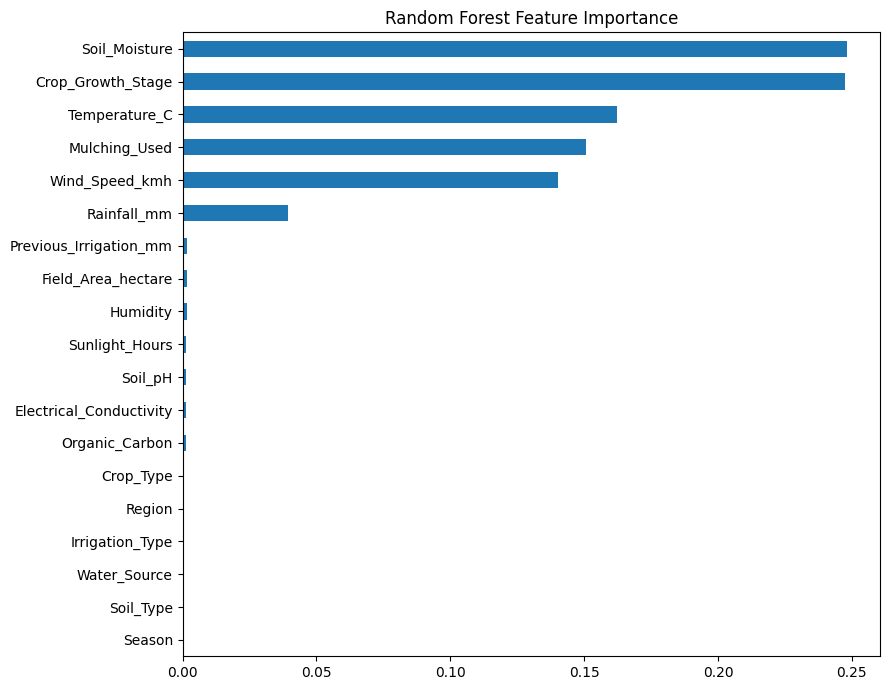

In [12]:
# feature importance
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(9, 7), title='Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [15]:
# refit on all training data, predict test set, save submission
rf_final = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
rf_final.fit(X, y_enc)
preds = rf_final.predict(X_test)
preds_labels = target_le.inverse_transform(preds)

submission = sample_sub.copy()
submission['Irrigation_Need'] = preds_labels
submission.to_csv('../submissions/bagging_submission.csv', index=False)
print(submission.head())

KeyboardInterrupt: 

In [14]:
submission = sample_sub.copy()
submission['Irrigation_Need'] = preds_labels
submission.to_csv('../submissions/bagging_submission.csv', index=False)
print(submission.head())

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low


In [16]:
submission = sample_sub.copy()
submission['Irrigation_Need'] = preds_labels
submission.to_csv('../submissions/bagging_submission.csv', index=False)
print(submission.head())
print(f'Rows: {len(submission)}')

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
Rows: 270000
